# Flight Delay Analysis Brazil 🇧🇷

## Análise dos atrasos em voos comerciais brasileiros - 2025

Autor: Nixon Deam

**Objetivo:** Identificar os fatores que influenciam os atrasos em voos comerciais brasileiros em 2025 e desenvolver um modelo capaz de prever atrasos superiores a 15 minutos.

# 1. Importação das bibliotecas

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

## 2. Carregamento dos dados

In [2]:
pasta_dados = Path("C:/Users/nixon/OneDrive/Área de Trabalho/Flight-Delay-Analysis-Brazil/data/raw")

arquivos_csv = list(pasta_dados.glob("*.csv"))

print(f"Arquivos CSV encontrados: {len(arquivos_csv)}")

Arquivos CSV encontrados: 12


# 3. Leitura e união dos arquivos

In [3]:
lista_dfs = []

for arquivo in arquivos_csv:
    df_tempo=pd.read_csv(
        arquivo,
        sep=";",
        skiprows=1,
        low_memory=False,

    )
    lista_dfs.append(df_tempo)

df = pd.concat(lista_dfs, ignore_index=True)

In [4]:
df = df.drop(columns=["Código Justificativa"])

In [5]:

df = df[df["Situação Voo"] == "REALIZADO"]

# 4. Preparação dos dados

In [6]:
colunas_data = [
    "Partida Prevista",
    "Partida Real",
    "Chegada Prevista",
    "Chegada Real"
]

In [7]:
for coluna in colunas_data:
    df[coluna] = pd.to_datetime(
        df[coluna],
        format="mixed",
        errors="coerce"
    )

In [8]:
df["Atraso Partida (min)"] = (
    df["Partida Real"] - df["Partida Prevista"]
).dt.total_seconds() / 60

df["Atraso Chegada (min)"] = (
    df["Chegada Real"] - df["Chegada Prevista"]
).dt.total_seconds() / 60

In [9]:
df[["Atraso Partida (min)", "Atraso Chegada (min)"]].head()

,Atraso Partida (min),Atraso Chegada (min)
0,3.0,-6.0
1,90.0,82.0
2,21.0,-6.0
3,94.0,83.0
5,31.0,14.0


In [10]:
df["Atrasou"] = df["Atraso Chegada (min)"] > 0

In [11]:
df["Atrasou"].value_counts()

Atrasou
False    629909
True     348183
Name: count, dtype: int64

In [12]:
df["Atrasou"].value_counts(normalize=True) * 100

Atrasou
False    64.401815
True     35.598185
Name: proportion, dtype: float64

In [13]:
df["Ano"] = df["Partida Prevista"].dt.year
df["Mês"] = df["Partida Prevista"].dt.month
df["Dia"] = df["Partida Prevista"].dt.day
df["Hora"] = df["Partida Prevista"].dt.hour
df["Dia da Semana"] = df["Partida Prevista"].dt.day_name()

In [14]:
df[["Ano", "Mês", "Dia", "Hora", "Dia da Semana"]].head()

,Ano,Mês,Dia,Hora,Dia da Semana
0,2025.0,1.0,17.0,1.0,Friday
1,2025.0,1.0,18.0,1.0,Saturday
2,2025.0,1.0,19.0,1.0,Sunday
3,2025.0,1.0,20.0,1.0,Monday
5,2025.0,1.0,1.0,19.0,Wednesday


In [15]:
aeroportos = {
    "SBGR": "GRU (Guarulhos)",
    "SBSP": "CGH (Congonhas)",
    "SBKP": "VCP (Viracopos)",
    "SBCF": "CNF (Confins)",
    "SBGL": "GIG (Galeão)",
    "SBBR": "BSB (Brasília)",
    "SBRF": "REC (Recife)",
    "SBPA": "POA (Porto Alegre)",
    "SBSV": "SSA (Salvador)",
    "SBCT": "CWB (Curitiba)"
}

In [16]:
companhias = {
    # Brasileiras
    "AZU": "Azul",
    "ACN": "Azul Conecta",
    "GLO": "GOL",
    "TAM": "LATAM Brasil",
    "LAN": "LATAM Airlines",

    # América
    "AAL": "American Airlines",
    "UAL": "United Airlines",
    "DAL": "Delta Air Lines",
    "ACA": "Air Canada",
    "AVA": "Avianca",
    "CMP": "Copa Airlines",
    "ARG": "Aerolíneas Argentinas",
    "SKU": "SKY Airline",
    "JAT": "JetSMART",

    # Europa
    "AEA": "Air Europa",
    "AFR": "Air France",
    "BAW": "British Airways",
    "IBE": "Iberia",
    "DLH": "Lufthansa",
    "KLM": "KLM",
    "TAP": "TAP Air Portugal",
    "VLG": "Vueling",
    "IBE": "Iberia",

    # Oriente Médio
    "QTR": "Qatar Airways",
    "UAE": "Emirates",
    "ETH": "Ethiopian Airlines",
    "THY": "Turkish Airlines",

    # Ásia
    "CPA": "Cathay Pacific",
    "CES": "China Eastern",
    "CCA": "Air China",
}

In [17]:
df["Companhia"] = (
    df["ICAO Empresa Aérea"]
    .replace(companhias)
)

In [18]:
voos_por_empresa = df["Companhia"].value_counts()

In [19]:
empresas_validas = voos_por_empresa[
    voos_por_empresa >= 1000
].index

In [20]:
taxa_atraso = (
    df[df["Companhia"].isin(empresas_validas)]
      .groupby("Companhia")["Atrasou"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

taxa_atraso

Companhia
BOV                      75.725594
GTI                      60.289389
LAP                      59.428130
TAP Air Portugal         57.985185
LCO                      56.322254
ARE                      55.871067
Turkish Airlines         52.784856
CLX                      52.476669
Lufthansa                52.347418
SID                      51.542378
TPA                      50.509857
TTL                      49.925484
LTG                      49.665247
Air France               49.094259
FBZ                      48.710801
United Airlines          48.498783
LPE                      47.847055
American Airlines        47.525186
PTB                      46.067986
Avianca                  44.424674
Emirates                 44.018476
Qatar Airways            43.759036
Aerolíneas Argentinas    42.004387
Delta Air Lines          41.387642
Ethiopian Airlines       40.115942
JetSMART                 40.094999
Air Canada               40.077391
LATAM Brasil             39.897829
LATAM Airl

In [21]:
aeroportos.update({
    "SKBO": "BOG (Bogotá)",
    "LEMD": "MAD (Madrid)",
    "LFPG": "CDG (Paris)",
    "KMIA": "MIA (Miami)",
    "EHAM": "AMS (Amsterdã)"
})

In [22]:
atrasos_aeroporto = (
    df[df["Atrasou"]]
      .groupby("ICAO Aeródromo Origem")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

atrasos_aeroporto

ICAO Aeródromo Origem
SBGR    66536
SBSP    32621
SBKP    23302
SBCF    21504
SBGL    19776
SBBR    17679
SBRF    13412
SBPA     8624
SBSV     8596
SBCT     8519
dtype: int64

In [23]:
atrasos_aeroporto.index = (
    atrasos_aeroporto.index
    .map(lambda x: aeroportos.get(x, x))
)

atrasos_aeroporto

ICAO Aeródromo Origem
GRU (Guarulhos)       66536
CGH (Congonhas)       32621
VCP (Viracopos)       23302
CNF (Confins)         21504
GIG (Galeão)          19776
BSB (Brasília)        17679
REC (Recife)          13412
POA (Porto Alegre)     8624
SSA (Salvador)         8596
CWB (Curitiba)         8519
dtype: int64

In [24]:
df["Aeroporto Origem"] = (
    df["ICAO Aeródromo Origem"].replace(aeroportos)
)

df["Aeroporto Destino"] = (
    df["ICAO Aeródromo Destino"].replace(aeroportos)
)

# 4. Análise Exploratória dos Dados (EDA)

# 4.1 Panorama Geral

Nesta seção, será apresentada uma visão geral da base de dados, incluindo o volume de voos analisados e a proporção de voos que chegaram com atraso.

### Quantos voos ocorreram em 2025?

In [25]:
df.shape

(978092, 22)

### Qual o percentual de voos atrasados?

In [26]:
percentual_atrasos = (
    df["Atrasou"]
    .value_counts(normalize=True)
    .rename(index={
        False: "No horário ou adiantado",
        True: "Atrasado"
    })
    .mul(100)
    .round(2)
)

percentual_atrasos

Atrasou
No horário ou adiantado    64.4
Atrasado                   35.6
Name: proportion, dtype: float64

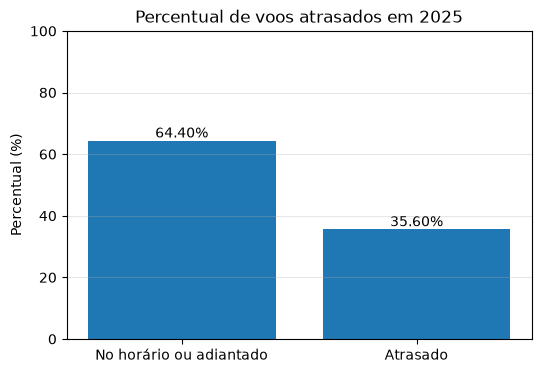

In [27]:
plt.figure(figsize=(6,4))

plt.bar(
    percentual_atrasos.index,
    percentual_atrasos.values
)

plt.title("Percentual de voos atrasados em 2025")
plt.ylabel("Percentual (%)")

for i, valor in enumerate(percentual_atrasos.values):
    plt.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center"
    )

plt.ylim(0,100)

plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretação

Dos **978.092 voos realizados** analisados, aproximadamente **64,4%** chegaram no horário previsto ou adiantados, enquanto **35,6%** apresentaram atraso na chegada.

Embora a maioria dos voos tenha sido concluidos dentro do horário esperado, mais de um terço dos voos sofreram atrasos. Portanto, evidencia-se a relevância de investigar quais fatores estão por trâs dos atrasos, afim de identificar padrões.

### 4.2 Companhias Aéreas

Nesta seção, serão analisadas quais companhias aéreas realizou mais voos no ano de 2025. com o objetivo de identificar quais empresas apresentaram maior volume de voos e maior frequência de atrasos, permitindo a análise comparativa entre o desempenho de cada companhia aérea.

### Qual companhia realizou mais voos?

Será analisada primeiramente a quantidade de voos realizados por cada companhia aéria, identificando quais empresas possuem o maior número de voos em 2025.



In [28]:
voos_empresa = (
    df["ICAO Empresa Aérea"]
    .value_counts()
    .head(10)
)
voos_empresa

ICAO Empresa Aérea
AZU    294573
TAM    286577
GLO    245549
ACN     15694
LAN     12051
TAP     10125
CMP      8758
ARG      8661
SKU      5729
AVA      5058
Name: count, dtype: int64

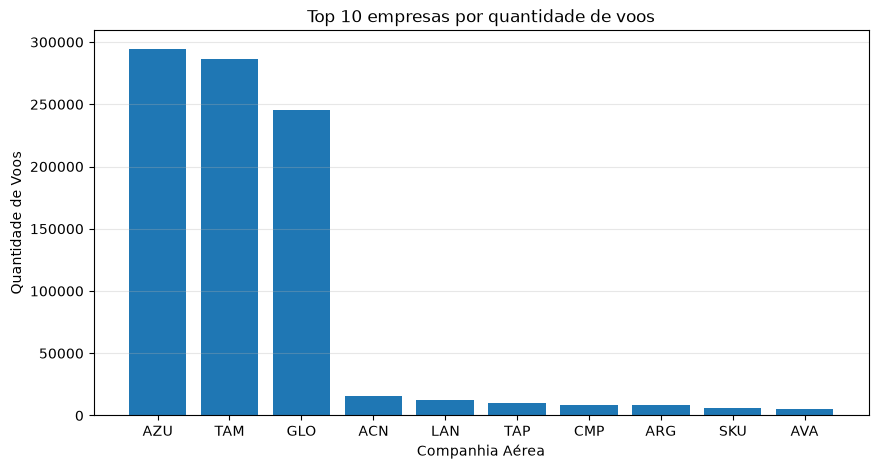

In [29]:
plt.figure(figsize=(10,5))

plt.bar(
    voos_empresa.index,
    voos_empresa.values
)

plt.title("Top 10 empresas por quantidade de voos")
plt.xlabel("Companhia Aérea")
plt.ylabel("Quantidade de Voos")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Interpretação

Observa-se que a companhia "AZU" ou seja, a Azul, é a empresa que mais realizou voos em 2025, seguidas pelas companhias TAM e GLO (GOL). Essas empresas possuem a maior representação de voos no mercado doméstico brasileiro, podendo também ser questão de análise dos motivos das empresas ACN, LAN, TAP, CMP, ARG, SKU e AVA, terem numeros tão inferiores as 3 primeiras companhias aereas no Brasil.

### Qual companhia aérea possui maior taxa de atraso?

Nesta análise, é calculada a porcentagem de voos atrasados por companhias aéreas. Esse calculo tem como objetivo de comparar a pontualidade entre as companhias aereas, independentemente de seu volume.

In [30]:
taxa_atraso = (
    df.groupby("ICAO Empresa Aérea")["Atrasou"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    )

In [31]:
df["Companhia"] = (
    df["ICAO Empresa Aérea"]
    .replace(companhias)
)

In [32]:
top_empresas = (
    df["Companhia"]
    .value_counts()
    .head(10)
    .index
)

taxa_atraso = (
    df[df["Companhia"].isin(top_empresas)]
      .groupby("Companhia")["Atrasou"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

taxa_atraso

Companhia
TAP Air Portugal         57.985185
Avianca                  44.424674
Aerolíneas Argentinas    42.004387
LATAM Brasil             39.897829
LATAM Airlines           37.565347
SKY Airline              35.852679
Azul Conecta             35.179049
Azul                     32.881832
GOL                      29.728486
Copa Airlines            25.633706
Name: Atrasou, dtype: float64

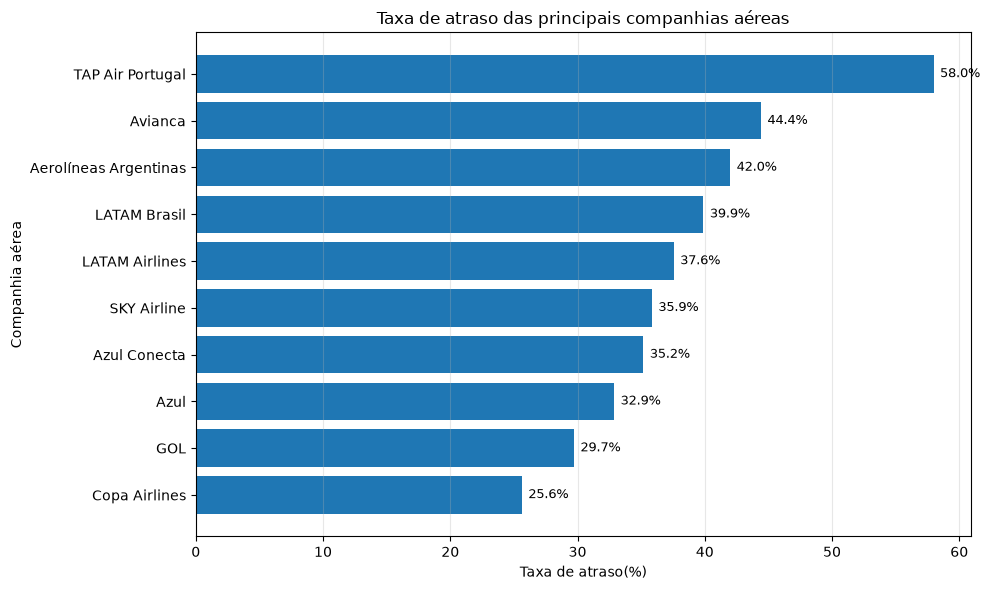

In [33]:
plt.figure(figsize=(10,6))

plt.barh(
    taxa_atraso.index,
    taxa_atraso.values
)

plt.title("Taxa de atraso das principais companhias aéreas")
plt.xlabel("Taxa de atraso(%)")
plt.ylabel("Companhia aérea")

plt.grid(axis="x", alpha=0.3)

plt.gca().invert_yaxis()

for i, valor in enumerate(taxa_atraso.values):
    plt.text(
        valor + 0.5,
        i,
        f"{valor:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

### Interpretação

Foi utilizado filtros para as empresas que mais fizeram voos, ignorando as empresas de pequeno porte ou que fizeram pouquissimos voos nesta análise.

Entre as companhias analisadas, a GOL e a Copa Airlines apresentaram menores taxas de atrasos (aproximadamente 29,7%), enquanto outras empresas como a TAP Air portugal e Avianca registraram os maiores indices de atrasos no ano de 2025.

É necessario uma análise mais criteriosa, considerando caracteristicas individuais de cada companhia aerea para entender o motivo das taxas de atrasos.

### 4.3 Aeroportos

Nesta seção, serão analisadas quais aeroportos concentram a maior taxa de voos atrasados em 2025.

In [34]:
atrasos_aeroporto.index = (
    atrasos_aeroporto.index
    .map(lambda x: aeroportos.get(x, x))
)

atrasos_aeroporto

ICAO Aeródromo Origem
GRU (Guarulhos)       66536
CGH (Congonhas)       32621
VCP (Viracopos)       23302
CNF (Confins)         21504
GIG (Galeão)          19776
BSB (Brasília)        17679
REC (Recife)          13412
POA (Porto Alegre)     8624
SSA (Salvador)         8596
CWB (Curitiba)         8519
dtype: int64

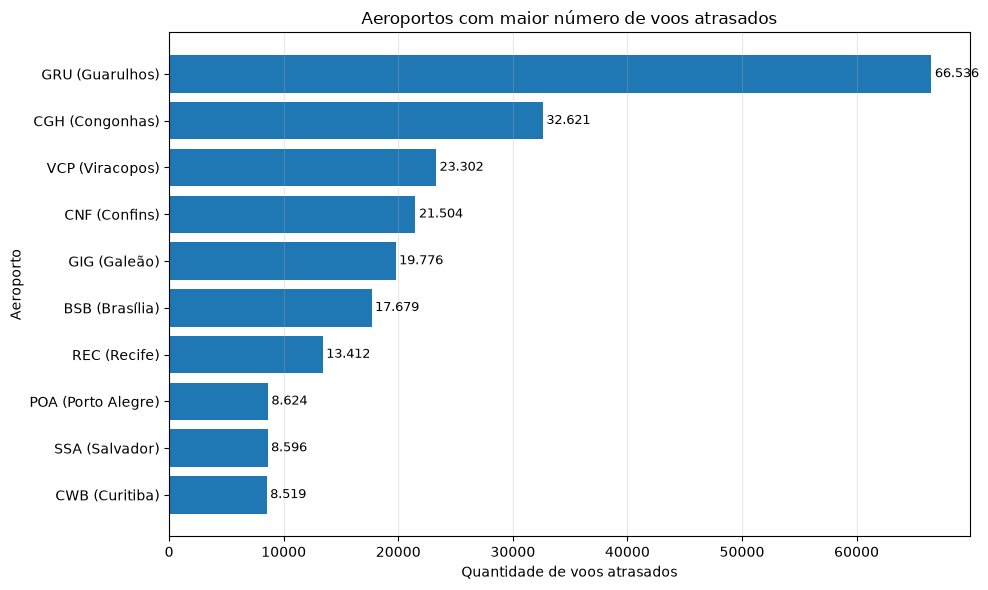

In [35]:
plt.figure(figsize=(10,6))

plt.barh(
    atrasos_aeroporto.index,
    atrasos_aeroporto.values
)

plt.title("Aeroportos com maior número de voos atrasados")
plt.xlabel("Quantidade de voos atrasados")
plt.ylabel("Aeroporto")

plt.grid(axis="x", alpha=0.3)

# Maior valor no topo
plt.gca().invert_yaxis()

# Valores nas barras
for i, valor in enumerate(atrasos_aeroporto.values):
    plt.text(
        valor + 300,
        i,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

### Interpretação

A análise confirma que no aeroporto de GRU (Guarulhos) concetrou a maior taxa de voos atrasados em 2025, seguido por CGH(Congonhas) e VCP(Viracopos). É interessante também afirmar que esses aeroportos estão entre os mais movimentados do país, o que pode explicar os atrasos.

Assim, é possivel observar que os aerportos localizados em grandes cidades possuem os maiores fluxos operacionais, possuindo maiores numeros de pousos e decolagens, o que az aumentar as chances de atrasos nos voos.

É importante ressaltar que essa analise contmém a quantidade absoluta de voos atrasados, e não taxa de cada aeroporto. O que significa que naturalmente os aeroportos mais movimentados e com mair quantidade de voos tendem a registrar mais os numeros de atrasos.

### 4.4 Horário

 Nesta seção, será possivel investigarmos se existe relação entre a taxa de voos atrasados e o horario de maior intensidade operacional nos principais aeroportos brasileiros.

In [36]:
top5_aeroportos = (
    df["ICAO Aeródromo Origem"]
      .value_counts()
      .head(5)
      .index
)

atrasos_hora_aeroporto = (
    df[df["ICAO Aeródromo Origem"].isin(top5_aeroportos)]
      .groupby(["ICAO Aeródromo Origem", "Hora"])["Atrasou"]
      .mean()
      .mul(100)
      .reset_index()
)

atrasos_hora_aeroporto["ICAO Aeródromo Origem"] = (
    atrasos_hora_aeroporto["ICAO Aeródromo Origem"]
      .replace(aeroportos)
)

atrasos_hora_aeroporto


,ICAO Aeródromo Origem,Hora,Atrasou
0,BSB (Brasília),0.0,40.909091
1,BSB (Brasília),1.0,18.469657
2,BSB (Brasília),2.0,11.320755
3,BSB (Brasília),3.0,11.538462
4,BSB (Brasília),4.0,17.356688
...,...,...,...
108,CGH (Congonhas),18.0,45.131828
109,CGH (Congonhas),19.0,44.210726
110,CGH (Congonhas),20.0,33.267483
111,CGH (Congonhas),21.0,39.919611


In [37]:
atrasos_hora_aeroporto["ICAO Aeródromo Origem"] = (
    atrasos_hora_aeroporto["ICAO Aeródromo Origem"]
    .replace(aeroportos)
)

In [38]:
import seaborn as sns

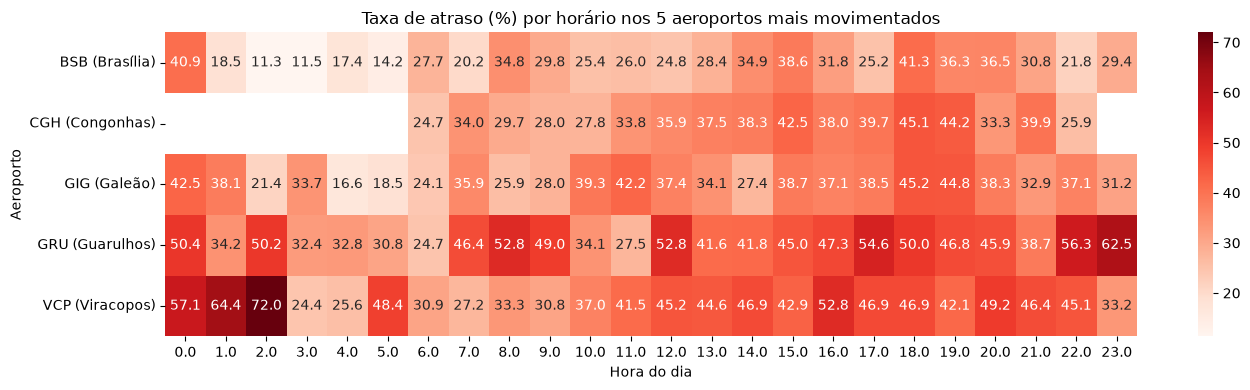

In [39]:
heatmap = (
    atrasos_hora_aeroporto
    .pivot(
        index="ICAO Aeródromo Origem",
        columns="Hora",
        values="Atrasou"
    )
)

plt.figure(figsize=(14,4))

sns.heatmap(
    heatmap,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Taxa de atraso (%) por horário nos 5 aeroportos mais movimentados")
plt.xlabel("Hora do dia")
plt.ylabel("Aeroporto")

plt.tight_layout()
plt.show()

### Interpretação

Observa-se que a taxa de atrasos em voos no ano de 2025 variam ao longo do dia. Em diferentes aeroportos, as taxas de atrasos atingem valores mais elevados no final da tarde e inicio da noite. Nesse sentido, esses resultados sugerem que há maiores probabilidades de atrasos em voos durante os horários de maior movimentação em aeroportos, como no fim da tarde, por exemplo. Entretanto, essa analise é descritiva e não permite concluir que o horário seja a causa dos atrasos, podendo ter outros fatores a ser considerados numa analise mais profunda.




### 4.5 Dia da semana

 Nesta seção, será possível investigarmos se existe nexo-causal entre a taxa de voos atrasados e os dias de maior intensidade operacional nos principais aeroportos brasileiros.

In [40]:
atraso_dia_semana = (
    df.groupby("Dia da Semana")["Atrasou"]
      .mean()
      .mul(100)
)

ordem = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

atraso_dia_semana = atraso_dia_semana.reindex(ordem)

dias = {
    "Monday": "Segunda",
    "Tuesday": "Terça",
    "Wednesday": "Quarta",
    "Thursday": "Quinta",
    "Friday": "Sexta",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

atraso_dia_semana.index = atraso_dia_semana.index.map(dias)

atraso_dia_semana

Dia da Semana
Segunda    37.294190
Terça      37.420353
Quarta     38.016652
Quinta     39.371190
Sexta      40.209866
Sábado     30.946368
Domingo    32.421923
Name: Atrasou, dtype: float64

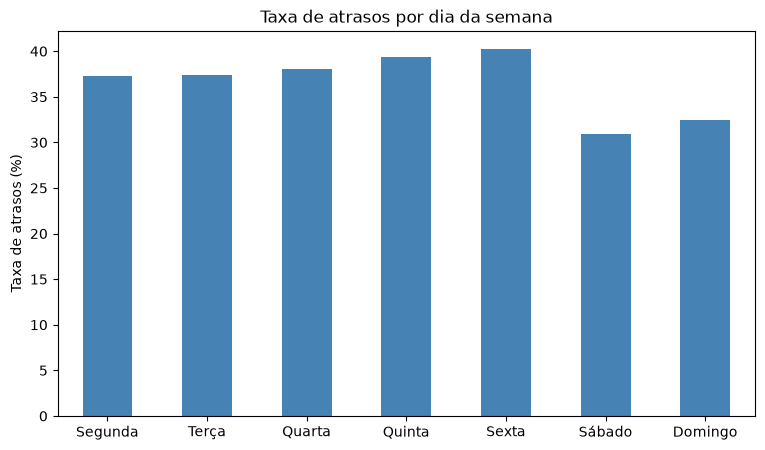

In [41]:
plt.figure(figsize=(9,5))

atraso_dia_semana.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Taxa de atrasos (%)")
plt.xlabel("")
plt.title("Taxa de atrasos por dia da semana")
plt.xticks(rotation=0)

plt.show()

### Interpretação

Observa-se que as taxas de voos atrasados ao longo da semana permanecem concentradas de maneira parecida, entretanto, na sexta-feira, essa taxa bate o maior registro (40,2%). Em contrapartida, o sabado apresenta a menor taxa de atrasos com (30,9%). Esses resultados sugerem que os dias úteis apresentam maior probabilidade de atrasos quando comparados ao fim de semana. Entretanto, esta é uma analise descritiva, sendo necessários mais estudos para uma melhor compreensão desse fenômeno.

### 4.6 Sazonalidade

Nesta seção, vamos analisar a sazonalidade dos atrasos de voos ao longo do ano de 2025. A sazonalidade pode revelar padrões relacionados a períodos específicos, como férias, feriados ou eventos especiais que impactam o tráfego aéreo e, consequentemente, os atrasos.

In [42]:
atraso_mes = (
    df.groupby("Mês")["Atrasou"]
      .mean()
      .mul(100)
)

atraso_mes 

Mês
1.0     37.435806
2.0     37.781109
3.0     31.522240
4.0     36.226410
5.0     33.066778
6.0     36.706705
7.0     35.568751
8.0     33.040946
9.0     33.190729
10.0    37.180442
11.0    38.577426
12.0    49.195397
Name: Atrasou, dtype: float64

In [43]:
meses = {
    1:"Jan",
    2:"Fev",
    3:"Mar",
    4:"Abr",
    5:"Mai",
    6:"Jun",
    7:"Jul",
    8:"Ago",
    9:"Set",
    10:"Out",
    11:"Nov",
    12:"Dez"
}

atraso_mes.index = atraso_mes.index.map(meses)

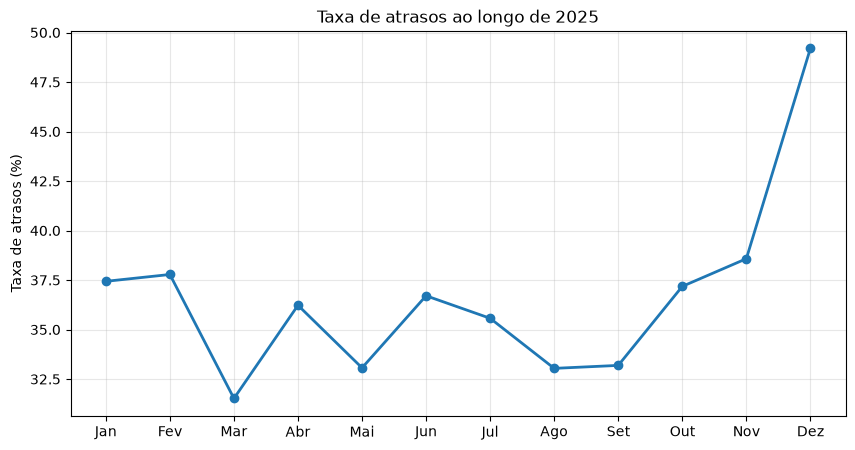

In [44]:
plt.figure(figsize=(10,5))

plt.plot(
    atraso_mes.index,
    atraso_mes.values,
    marker="o",
    linewidth=2
)

plt.ylabel("Taxa de atrasos (%)")
plt.title("Taxa de atrasos ao longo de 2025")

plt.grid(alpha=.3)

plt.show()

### Interpretação

Podemos verificar, conforme o gráfico, que ao longo de 2025, é sugerido uma existência de sazonalidade. O mês de dezembro registrou a maior taxa de atrasos de voos (49,2%), diferença significativa com os demais meses. Esse comportamento pode estar ligado ao período de férias e festas de final de ano. Assim, numa análise descritiva, não permite afirmar que o aumento da demanda seja também uma causa dos aumentos das taxas de atrasos de voos, sendo necessários estudos mais aprofundados para sua confirmação.

### 5. Machine Learning

Nesta etapa, será desenvolvido um modelo de Machine Learning capaz de prever se um voo sofrerá atrasos. Será utilizado apenas as informações aqui disponiveis antes da decolagem.

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
features = [
    "Companhia",
    "ICAO Aeródromo Origem",
    "ICAO Aeródromo Destino",
    "Hora",
    "Dia da Semana",
    "Mês"
]

In [47]:
x = df[features]

y = df["Atrasou"]

In [48]:
df["ICAO Aeródromo Origem"] = (
    df["ICAO Aeródromo Origem"]
    .replace(aeroportos)
)

In [49]:
df["ICAO Aeródromo Destino"] = (
    df["ICAO Aeródromo Destino"]
    .replace(aeroportos)
)

In [50]:
x = df[features]

x.head()

,Companhia,ICAO Aeródromo Origem,ICAO Aeródromo Destino,Hora,Dia da Semana,Mês
0,Avianca,GRU (Guarulhos),BOG (Bogotá),1.0,Friday,1.0
1,Avianca,GRU (Guarulhos),BOG (Bogotá),1.0,Saturday,1.0
2,Avianca,GRU (Guarulhos),BOG (Bogotá),1.0,Sunday,1.0
3,Avianca,GRU (Guarulhos),BOG (Bogotá),1.0,Monday,1.0
5,Air Europa,MAD (Madrid),GRU (Guarulhos),19.0,Wednesday,1.0


In [51]:
x = pd.get_dummies(x, drop_first=True)

In [52]:
df["Companhia"].value_counts().sort_index()

Companhia
1ED                  43
ABD                  13
ABJ                1280
AEB                  29
AJB                  15
                   ... 
UPS                 780
USY                   8
United Airlines    3697
VCV                 100
VTU                   6
Name: count, Length: 106, dtype: int64

In [53]:
top_companhias = [
    "Azul",
    "GOL",
    "LATAM Brasil",
    "Azul Conecta",
    "LATAM Airlines",
    "TAP Air Portugal",
    "Copa Airlines",
    "Aerolíneas Argentinas",
    "SKY Airline",
    "Avianca"
]

df_ml = df[df["Companhia"].isin(top_companhias)].copy()

In [54]:
x = df_ml[features]
y = df_ml["Atrasou"]

In [55]:
x = pd.get_dummies(x, drop_first=True)

In [56]:
df_ml["Companhia"].value_counts()

Companhia
Azul                     294573
LATAM Brasil             286577
GOL                      245549
Azul Conecta              15694
LATAM Airlines            12051
TAP Air Portugal          10125
Copa Airlines              8758
Aerolíneas Argentinas      8661
SKY Airline                5729
Avianca                    5058
Name: count, dtype: int64

In [57]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
print(f"Treino: {x_train.shape}")
print(f"Teste: {x_test.shape}")

print(f"Treino (target): {y_train.shape}")
print(f"Teste (target): {y_test.shape}")

Treino: (714220, 515)
Teste: (178555, 515)
Treino (target): (714220,)
Teste (target): (178555,)


In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [61]:
modelo.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [62]:
y_pred = modelo.predict(x_test)

In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.6566


In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.72      0.77      0.75    116495
        True       0.51      0.44      0.47     62060

    accuracy                           0.66    178555
   macro avg       0.61      0.61      0.61    178555
weighted avg       0.65      0.66      0.65    178555



In [65]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[89824, 26671],
       [34646, 27414]])

In [66]:
importancia = pd.DataFrame({
    "Variável": x.columns,
    "Importância": modelo.feature_importances_
}).sort_values("Importância", ascending=False)

importancia.head(20)

,Variável,Importância
1,Mês,0.436530
0,Hora,0.235540
24,ICAO Aeródromo Origem_GRU (Guarulhos),0.015748
509,Dia da Semana_Monday,0.015716
513,Dia da Semana_Tuesday,0.014898
514,Dia da Semana_Wednesday,0.014508
510,Dia da Semana_Saturday,0.011344
512,Dia da Semana_Thursday,0.010922
511,Dia da Semana_Sunday,0.009507
8,Companhia_LATAM Brasil,0.008082


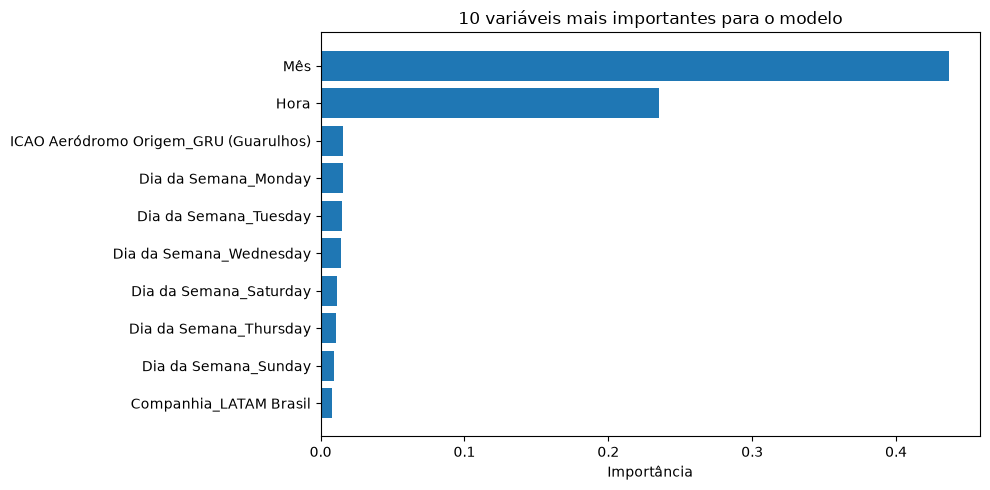

In [67]:
import matplotlib.pyplot as plt

top10 = importancia.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10["Variável"], top10["Importância"])
plt.gca().invert_yaxis()

plt.title("10 variáveis mais importantes para o modelo")
plt.xlabel("Importância")

plt.tight_layout()
plt.show()

# 6. Conclusão

Neste projeto, foi realizada uma análise detalhada dos atrasos de voos no Brasil durante o ano de 2025. Através da exploração dos dados, foi possível identificar padrões e tendências relacionadas aos atrasos, incluindo a influência de companhias aéreas, aeroportos, horários e dias da semana.

O modelo Random Forest alcançou uma acurácia de aproximadamente 65,7%, demonstrando capacidade moderada de classificação utilizando apenas informações disponíveis antes da decolagem.

Este projeto ilustra um fluxo completo de Ciência de Dados, desde a coleta e preparação dos dados até a avaliação de um modelo preditivo.